In [ ]:
from misc import *
import constant

# upto 5 long track candidates isMuon
LTRACK5_HIGH_MASS_FILE_PATH = "/dice/projects/LHCb/PbPb_MSCi/LeadLead_dimuon_HighMass_all.root"
DEFAULT_TREE_NAME = "dimuonTuple/DecayTree"

no_ismuon_df = load_root(LTRACK5_HIGH_MASS_FILE_PATH, DEFAULT_TREE_NAME)
all_pT_df = no_ismuon_df[(no_ismuon_df["muplus_isMuon"] == True) & (no_ismuon_df["muminus_isMuon"] == True)]
df = all_pT_df
# df = all_pT_df[all_pT_df["J_psi_1S_PT"] < 1000]

In [1]:
bin_width = 0.3

fig, ax = histogram_fig(
    [
        HistogramPlot(
            log_pT2(df["J_psi_1S_PT"] / 1e3),
            "All",
            bins=bin_width,
            linewidth=1.5,
            error=True,
        ),
        HistogramPlot(
            log_pT2(df["J_psi_1S_PT"][df["nVeloTracks"] == 2] / 1e3),
            "nVeloTracks = 2",
            bins=bin_width,
            linewidth=1.5,
            error=True,
        ),
    ],
    False,
    xlabel=r"$\ln{(p_T^2)}$",
    unit_tex=r"\ln(\mathrm{GeV}^2/c^2)",
)


bin_width = 100 / 1e3
fig, ax = histogram_fig(
    [
        HistogramPlot(
            df["J_psi_1S_M"] / 1e3,
            "All",
            bins=bin_width,
            linewidth=1.5,
            error=False,
        ),
        HistogramPlot(
            df["J_psi_1S_M"][df["nVeloTracks"] == 2] / 1e3,
            "nVeloTracks = 2",
            bins=bin_width,
            linewidth=1.5,
            error=False,
        ),
    ],
    False,
    xlabel=r"Mass",
    unit_tex=r"\mathrm{GeV}/c^2",
    xlim=[8, 21],
)

df = df[df["nVeloTracks"] == 2]

NameError: name 'histogram_fig' is not defined

In [ ]:
def add_upsilon(ax, xS, scale=1, **kwargs):
    for i in xS:
        mass = eval(f"constant.UPSILON_{i}S_MASS")
        label = r"$M(\Upsilon\mathrm{(" + f"{i}" + r"S)})$"
        ax.axvline(mass*scale, color="k", linewidth=1.5, label=label, ls="--", **kwargs)

In [ ]:
import json, pprint

json_path = "/dice/projects/LHCb/PbPb_MSCi/01_Fit_coherent_contributions/Fit_result.json"

with open(json_path, "r") as f:
    fit_result = json.load(f)

# pprint.pprint(fit_result)

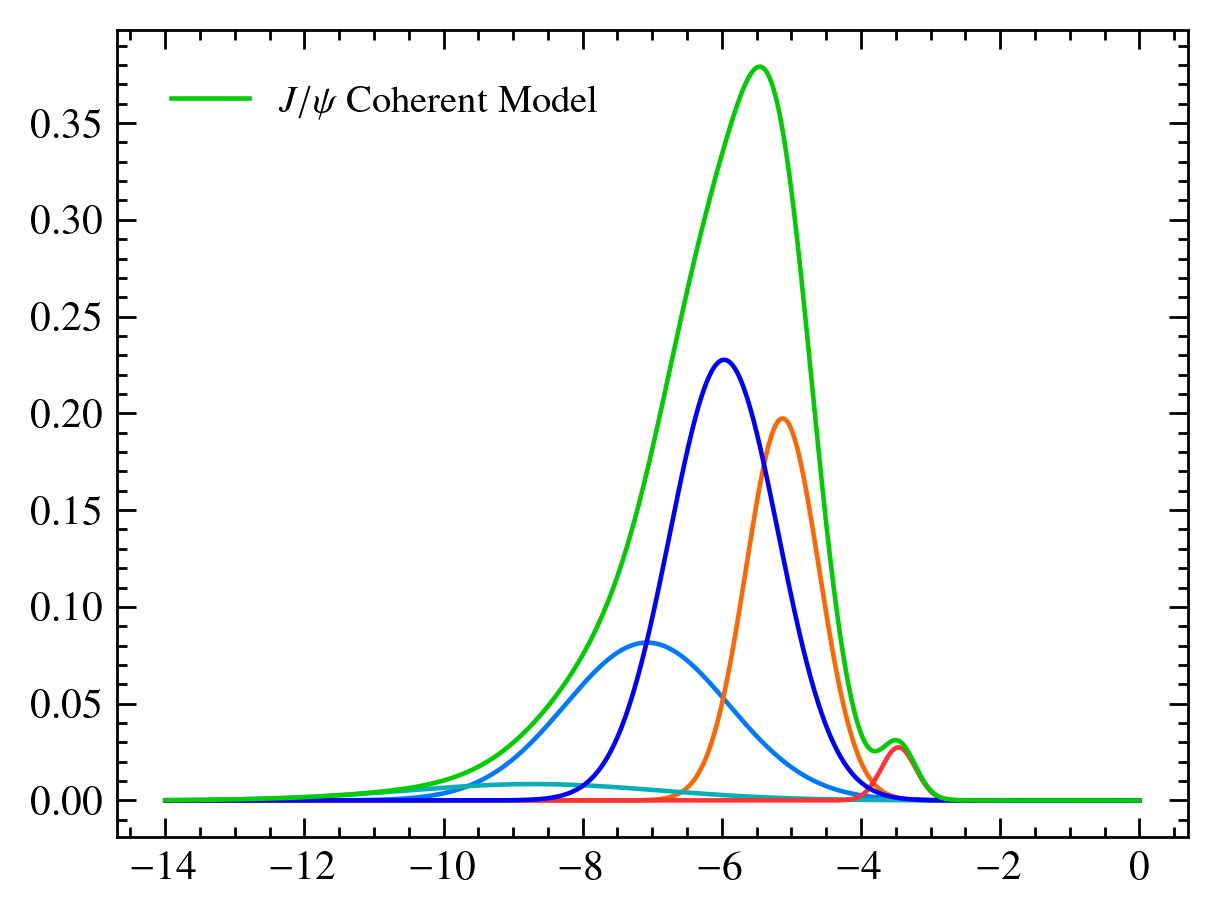

In [ ]:
import scipy.stats

x = np.linspace(-14, 0, 1000)

fig, ax = plt.subplots()

MC_jpsi_coh = fit_result["MC_Jpsi_coherent"]
gaussians = []
for (mu, sigma, _yield_model, frac) in zip(MC_jpsi_coh["mu"], MC_jpsi_coh["sigma"], MC_jpsi_coh["yield_model"], MC_jpsi_coh["frac"]):
    y = scipy.stats.norm.pdf(x, mu, sigma)*frac
    gaussians.append(y)
    ax.plot(x, y)

ax.plot(x, sum(gaussians), label=r"$J/\psi$ Coherent Model")
ax.legend()

In [ ]:
import zfit

/software/ai21208/Code/venv/lib/python3.12/site-packages/zfit/__init__.py:60: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(
2025-03-11 22:53:48.637967: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741733628.659703 2838593 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741733628.666655 2838593 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
mu_delta = zfit.Parameter("mu_delta", 0, floating=True)
def gauss_sum(obs, mus, sigmas, fracs):
    gaussians = []
    for mu, sigma in zip(mus, sigmas):
        shited_mu = zfit.ComposedParameter(f"{mu=}Gaussian", mu + mu_delta, params=mu_delta)
        gaussians.append(zfit.pdf.Gauss(obs=obs, mu=shited_mu, sigma=sigma))

    pdf = zfit.pdf.SumPDF(gaussians, fracs[:-1])

    return pdf


observables = {
    "lnpt2": zfit.Space("lnpt2", -14, 3),
    "M": zfit.Space("M", 9, 20),
}
data = {
    "lnpt2": zfit.data.from_numpy(
        array=(log_pT2(df["J_psi_1S_PT"] / 1e3)).to_numpy(), obs=observables["lnpt2"]
    ),
    "M": zfit.data.from_numpy(
        array=(df["J_psi_1S_M"] / 1e3).to_numpy(), obs=observables["M"]
    ),
}
yields = {
    "Jpsi_coh_Nsig": zfit.Parameter("Jpsi_coh_Nsig", 50),
    "Jpsi_incoh_Nsig": zfit.Parameter("Jpsi_incoh_Nsig", 50),
    "Nbkg": zfit.Parameter("Nbkg", 650),
}
pdfs = {
    # coherent pdfs
    "Jpsi_coh_lnpt2": gauss_sum(
        obs=observables["lnpt2"],
        mus=MC_jpsi_coh["mu"],
        sigmas=MC_jpsi_coh["sigma"],
        fracs=MC_jpsi_coh["frac"],
    ).create_extended(yields["Jpsi_coh_Nsig"]),

    "Jpsi_coh_M": zfit.pdf.Gauss(
        obs=observables["M"],
        mu=constant.UPSILON_1S_MASS / 1e3,
        sigma=zfit.Parameter(
            "Jpsi_coh_M_sigma", constant.UPSILON_1S_SIGMA_LHCB / 1e3, floating=False
        ),
    ).create_extended(yields["Jpsi_coh_Nsig"]),

    # incoherent pdfs
    # ln pT^2: KDE
    "Jpsi_incoh_M": zfit.pdf.Gauss(
        obs=observables["M"],
        mu=constant.UPSILON_1S_MASS / 1e3,
        sigma=zfit.Parameter(
            "Jpsi_incoh_M_sigma", constant.UPSILON_1S_SIGMA_LHCB / 1e-3, floating=False
        ),
    ).create_extended(yields["Jpsi_incoh_Nsig"]),

    # background pdf
    # ln pT^2: KDE
    "bkg_M": zfit.pdf.Exponential(
        obs=observables["M"], lambda_=zfit.Parameter("bkg_M_lambda", -0.4)
    ).create_extended(yields["Nbkg"]),
}

2025-03-11 22:53:54.044566: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_SYSTEM_DRIVER_MISMATCH: system has unsupported display driver / cuda driver combination
2025-03-11 22:53:54.044740: E external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:262] kernel version 555.42.6 does not match DSO version 570.124.6 -- cannot find working devices in this configuration


TypeError: <tf.Tensor: shape=(), dtype=float64, numpy=-7.075512226970559> is not a callable object

In [ ]:
background_df = df[df["J_psi_1S_M"] > 12e3]

bkg_data = zfit.data.from_numpy(array=(log_pT2(background_df["J_psi_1S_PT"]/1e3)).to_numpy(), obs=observables["lnpt2"])
bkg_kde = zfit.pdf.KDE1DimExact(obs=observables["lnpt2"], data=bkg_data)

pdfs["bkg_lnpt2"] = bkg_kde
pdfs["bkg_lnpt2"].set_yield(yields["Nbkg"])

x = np.linspace(float(bkg_kde.space.lower), float(bkg_kde.space.upper), 500)
bin_width = 0.2

fig, ax = histogram_fig(
    [HistogramPlot(np.log((background_df["J_psi_1S_PT"]/1e3)**2), "Background Candidates", bins=bin_width, linewidth=1.5, error=True)],
    False,
    xlabel = r"$\ln{(p_T^2)}$",
    unit_tex = r"\ln(\mathrm{GeV}^2/c^2)",
    density=True
)
ax.plot(x, bkg_kde.pdf(x), label="Background KDE pdf")
add_log_pt_axis(ax, "GeV")
ax.legend()

In [ ]:
coh_model = zfit.pdf.ProductPDF(pdfs=[pdfs["Jpsi_coh_M"], pdfs["Jpsi_coh_lnpt2"]]).create_extended(yields["Jpsi_coh_Nsig"])
# incoh_model = zfit.pdf.ProductPDF(pdfs=[pdfs["Jpsi_incoh_M"], pdfs["Jpsi_incoh_lnpt2"]]).create_extended(yields["Jpsi_incoh_Nsig"])
bkg_model = zfit.pdf.ProductPDF(pdfs=[pdfs["bkg_M"], pdfs["bkg_lnpt2"]]).create_extended(yields["Nbkg"])

total_model = zfit.pdf.SumPDF(pdfs=[coh_model, bkg_model])

In [ ]:
mass_data = (df["J_psi_1S_M"]/1e3).to_numpy()
lnpt2_data = (log_pT2(df["J_psi_1S_PT"]/1e3)).to_numpy()

combined_array = np.column_stack((mass_data, lnpt2_data))

total_data = zfit.Data.from_numpy(
    obs=["M", "lnpt2"],
    array=combined_array
)

nll = zfit.loss.ExtendedUnbinnedNLL(model=total_model, data=total_data)

minimizer = zfit.minimize.Minuit()
minimum = minimizer.minimize(nll)
minimum.hesse()
minimum.errors()

print(minimum)

In [ ]:
bin_width = 0.3
fig, ax = histogram_fig(
    [HistogramPlot(log_pT2(df["J_psi_1S_PT"]/1e3), "Data", bins=bin_width, linewidth=1.5, error=True)],
    False,
    xlabel = r"$\ln{(p_T^2)}$",
    unit_tex = r"\ln(\mathrm{GeV}^2/c^2)",
)

x = np.linspace(float(observables["lnpt2"].lower), float(observables["lnpt2"].upper), 500)
y = total_model.create_projection_pdf(obs="lnpt2").ext_pdf(x)*bin_width
ax.plot(x, y, label="Total", linewidth=1.5)
ax.plot(x, pdfs["Jpsi_coh_lnpt2"].ext_pdf(x)*bin_width, label="Coherent", linewidth=1.5)
# ax.plot(x, pdfs["Jpsi_incoh_lnpt2"].ext_pdf(x)*bin_width, label="Incoherent", linewidth=1.5)
ax.plot(x, pdfs["bkg_lnpt2"].ext_pdf(x)*bin_width, label="Background", linewidth=1.5)
add_log_pt_axis(ax, "GeV")
ax.legend()

In [ ]:
bin_width = 100/1e3
fig, ax = histogram_fig(
    [HistogramPlot(df["J_psi_1S_M"]/1e3, "Data", bins=bin_width, linewidth=1.5)],
    False,
    xlabel = r"Mass",
    unit_tex = r"\mathrm{GeV}/c^2",
    xlim=[8, 21]
)

x = np.linspace(float(observables["M"].lower), float(observables["M"].upper), 500)
y = total_model.create_projection_pdf(obs="M").ext_pdf(x)*bin_width
ax.plot(x, y, label="Total", linewidth=1.5)
ax.plot(x, pdfs["Jpsi_coh_M"].ext_pdf(x)*bin_width, label="Coherent", linewidth=1.5)
# ax.plot(x, pdfs["Jpsi_incoh_M"].ext_pdf(x)*bin_width, label="Incoherent", linewidth=1.5)
ax.plot(x, pdfs["bkg_M"].ext_pdf(x)*bin_width, label="Background", linewidth=1.5)
ax.legend()

In [ ]:
bin_width = 30/1e3
fig, ax = histogram_fig(
    [HistogramPlot(df["J_psi_1S_M"]/1e3, "Data", bins=bin_width, linewidth=1.5, error=True)],
    False,
    xlabel = r"Mass",
    unit_tex = r"\mathrm{GeV}/c^2",
    xlim=[9, 11]
)

x = np.linspace(9, 11, 500)
y = total_model.create_projection_pdf(obs="M").ext_pdf(x)*bin_width
ax.plot(x, y, label="Total", linewidth=1.5)
ax.plot(x, pdfs["Jpsi_coh_M"].ext_pdf(x)*bin_width, label="Coherent", linewidth=1.5)
# ax.plot(x, pdfs["Jpsi_incoh_M"].ext_pdf(x)*bin_width, label="Incoherent", linewidth=1.5)
ax.plot(x, pdfs["bkg_M"].ext_pdf(x)*bin_width, label="Background", linewidth=1.5)

add_upsilon(ax, scale=1/1000, xS=range(1,2))
ax.legend()


In [ ]:
M_fit_pdf = total_model.create_projection_pdf(obs="M")
lnpt2_fit_pdf = total_model.create_projection_pdf(obs="lnpt2")

n = 1e6
M_sample = M_fit_pdf.sample(n=n).to_numpy()
lnpt2_sample = lnpt2_fit_pdf.sample(n=n).to_numpy()

In [ ]:
bin_width = 4
fig, ax = histogram_fig(
    [HistogramPlot((df["J_psi_1S_M"]/1e3)*log_pT2(df["J_psi_1S_PT"]/1e3), "Data", bins=bin_width),
     HistogramPlot(M_sample*lnpt2_sample, f"Sample {n=:.2e}", bins=bin_width/10)],
    False,
    xlabel = r"$M \cdot \ln{(p_T^2)}$",
    unit_tex = r"\mathrm{GeV}/c^2 \cdot \ln(\mathrm{GeV}^2/c^2)",
    density=True
)

In [ ]:
M_vals = np.linspace(8.5, 20, 20)
lnpt2_vals = np.linspace(-14, 0, 20)
X, Y = np.meshgrid(M_vals, lnpt2_vals)

# Evaluate the PDF from zfit on the grid
pdf_vals = np.array([
    [total_model.pdf(np.array([[M, lnpt2]])).numpy()[0] for M in M_vals] 
    for lnpt2 in lnpt2_vals
])

In [ ]:
fig, ax = plt.subplots()

ax.contourf(X, Y, pdf_vals, levels=30, cmap="plasma")  # Adjust cmap as needed
ax.set(xlabel="Mass", ylabel=r"$\ln(p_T^2)$")

In [ ]:
fig, ax = plt.subplots()
ax.scatter(df["J_psi_1S_M"]/1e3, log_pT2(df["J_psi_1S_PT"]/1e3), s=1.5)
ax.set(ylim=[-14,0], xlim=[8.5,20])